RNNs, though being very <span style="color:red">expressive (can in principle be a universal approximator and be used to implement any algorithms)</span>, are not very easily optimizable with <span style="color:red">the 1st order gradient-based techniques</span>.

In [40]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Recap

#### Load data

In [41]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [42]:
len(words)

32033

#### Create vocabulary

In [43]:
tokens = sorted(list(set(''.join(words))))   # character-level
token_to_index = {token: i+1 for i, token in enumerate(tokens)}    # a dict
token_to_index['.'] = 0
index_to_token = {i: token for token, i in token_to_index.items()}   # a dict
vocabulary_size = len(index_to_token)

In [44]:
index_to_token

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [45]:
vocabulary_size

27

#### Build dataset

In [46]:
prefix_context_length = 3

def build_set(words):
    X = []   # inputs
    Y = []   # labels

    for word in words:
        context = [0] * prefix_context_length
        for token in word + '.':
            index = token_to_index[token]
            X.append(context)
            Y.append(index)
            context = context[1:] + [index]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print('inputs shape:', X.shape, 'labels shape:', Y.shape)

    return X, Y

random.shuffle(words)
n_train = int(len(words) * 0.8)
n_train_dev = int(len(words) * 0.9)

X_train, Y_train = build_set(words[:n_train])   # 80%
X_dev, Y_dev = build_set(words[n_train:n_train_dev])   # 10%
X_test, Y_test = build_set(words[n_train_dev:])   # 10%

inputs shape: torch.Size([182602, 3]) labels shape: torch.Size([182602])
inputs shape: torch.Size([22810, 3]) labels shape: torch.Size([22810])
inputs shape: torch.Size([22734, 3]) labels shape: torch.Size([22734])


#### Set up parameters

In [10]:
embedding_dimension = 10
n_hidden_neurons = 200

M = torch.randn(vocabulary_size, embedding_dimension)   # the embedding matrix
W_hidden = torch.randn(embedding_dimension * prefix_context_length, n_hidden_neurons)   # hidden layer weights
b_hidden = torch.randn(n_hidden_neurons)   # hidden layer bias
W_output = torch.randn(n_hidden_neurons, vocabulary_size)   # output layer weights
b_output = torch.randn(vocabulary_size)   # output layer bias

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters))

11897


#### Train the neural net

In [11]:
steps = 200000
decay_at_step = int(0.5 * steps)
learning_rate_start = 0.1
learning_rate_decay = 0.1 * learning_rate_start
minibatch_size = 32

log10_minibatch_losses = []

for i in range(steps):
    minibatch_indices = torch.randint(0, X_train.shape[0], (minibatch_size,))
    X_minibatch = X_train[minibatch_indices]
    Y_minibatch = Y_train[minibatch_indices]

    # forward pass
    input_embeddings = M[X_minibatch]
    input_embeddings_concatenated = input_embeddings.view(input_embeddings.shape[0], -1)
    hidden_layer_preactivation = input_embeddings_concatenated @ W_hidden + b_hidden
    hidden_layer_output = torch.tanh(hidden_layer_preactivation)
    logits = hidden_layer_output @ W_output + b_output
    minibatch_loss = F.cross_entropy(logits, Y_minibatch)

    # backward pass
    for p in parameters:
        p.grad = None
    minibatch_loss.backward()

    # parameter update
    learning_rate = learning_rate_start if i < decay_at_step else learning_rate_decay
    for p in parameters:
        p.data += -learning_rate * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"Loss for the minibatch at step {i} / {steps}: {minibatch_loss.item():.4f}")
    log10_minibatch_losses.append(minibatch_loss.log10().item())

Loss for the minibatch at step 0 / 200000: 29.2238
Loss for the minibatch at step 10000 / 200000: 2.8485
Loss for the minibatch at step 20000 / 200000: 2.0306
Loss for the minibatch at step 30000 / 200000: 2.5702
Loss for the minibatch at step 40000 / 200000: 2.6160
Loss for the minibatch at step 50000 / 200000: 2.3030
Loss for the minibatch at step 60000 / 200000: 2.5373
Loss for the minibatch at step 70000 / 200000: 2.7110
Loss for the minibatch at step 80000 / 200000: 2.5373
Loss for the minibatch at step 90000 / 200000: 2.3306
Loss for the minibatch at step 100000 / 200000: 2.4752
Loss for the minibatch at step 110000 / 200000: 2.1250
Loss for the minibatch at step 120000 / 200000: 2.1560
Loss for the minibatch at step 130000 / 200000: 2.3168
Loss for the minibatch at step 140000 / 200000: 2.0268
Loss for the minibatch at step 150000 / 200000: 1.6761
Loss for the minibatch at step 160000 / 200000: 2.0184
Loss for the minibatch at step 170000 / 200000: 2.0448
Loss for the minibatch 

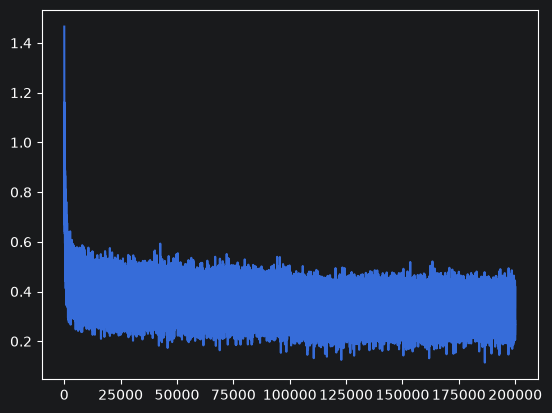

In [12]:
plt.plot(log10_minibatch_losses)

#### Check the performance

In [13]:
@torch.no_grad()   # a function's decorator: not constructing the computation graph for gradients.
def print_full_loss(split: str):
    x,y = {
        'train': (X_train, Y_train),
        'val': (X_dev, Y_dev),
        'test': (X_test, Y_test),
    }[split]

    input_embeddings = M[x]   # shape: (|x|, prefix_context_length, embedding_dimension)
    input_embeddings_concatenated = input_embeddings.view(input_embeddings.shape[0], -1)   # shape: (|x|, embedding_dimension * prefix_context_length)
    hidden_layer_output = torch.tanh(input_embeddings_concatenated @ W_hidden + b_hidden)   # shape: (|x|, n_hidden_neurons)
    logits = hidden_layer_output @ W_output + b_output   # shape: (|x|, vocabulary_size)
    full_loss = F.cross_entropy(logits, y)
    print('Full loss for the ' + split + ' set:', full_loss.item())

print_full_loss('train')
print_full_loss('val')

Full loss for the train set: 2.1551084518432617
Full loss for the val set: 2.190232276916504


#### Sample from the neural net

In [34]:
sample_size = 20

with torch.no_grad():
    for _ in range(sample_size):
        output_tokens = []
        prefix_context = [0] * prefix_context_length

        while True:
            input_embeddings = M[torch.tensor([prefix_context])]   # shape: (1, prefix_context_length, embedding_dimension)
            input_embeddings_concatenated = input_embeddings.view(1, -1)   # shape: (1, embedding_dimension * prefix_context_length)
            hidden_layer_output = torch.tanh(input_embeddings_concatenated @ W_hidden + b_hidden)   # shape: (1, n_hidden_neurons)
            logits = hidden_layer_output @ W_output + b_output   # shape: (1, vocabulary_size)
            output_probs = F.softmax(logits, dim=1)   # shape: (1, vocabulary_size)
            output_token_index = torch.multinomial(output_probs, num_samples=1).item()
            prefix_context = prefix_context[1:] + [output_token_index]
            output_tokens.append(output_token_index)
            if output_token_index == 0:
                break
        print(''.join(index_to_token[index] for index in output_tokens))

rak.
camyiann.
cori.
shaw.
jaznelllisa.
aler.
janan.
jayceen.
evor.
fha.
maz.
sothane.
evan.
faivannee.
analey.
lon.
kiran.
bia.
randemarakkiah.
elai.


### Fixing the confidently wrong initialization

Looking back at the minibatch loss (which can be seen as the full loss, as its expected value is the full loss) immediately after initialization: for my run it was around 29. This is too high because think of what we <ins>want</ins> at initialization: we want given any input context the next token is equally likely across the whole vocabulary since there should be no bias towards any tokens in any situations before the neural net sees any data.

In [38]:
expected_prob_for_all = torch.tensor(1/27.0)
print(f'Expected loss:  {-(expected_prob_for_all.log()).item():.4f}')

Expected loss:  3.2958


The reason for our initial loss being much larger than this wholesome value is because, with randomly initialized parameters, MLP tends to output logits with large gaps, making the softmax probability distribution confident on random tokens, which is often confidently wrong.

One way to achieve the above expected loss is to initialize the parameters such that the logits are all near $0$.

If we simply set all the weights and biases of the whole neural net to $0$, the logits will be all $0$ immediately. But then, gradient descent will not update any parameters apart from the final linear layer's bias.

To make all logits near $0$, the "closest" set of parameters to manipulate is the weights and biases in the final linear layer. We can set all the biases in this output layer to $0$ (we do not have perference towards any tokens at the start of the training), and set all its weights to near $0$ (we don't want the weights to be exactly $0$ to avoid blocking signals transmitting from the hidden layer to the output layer. Although for this specific case it may be alright).

In [47]:
embedding_dimension = 10
n_hidden_neurons = 200

M = torch.randn(vocabulary_size, embedding_dimension)   # the embedding matrix
W_hidden = torch.randn(embedding_dimension * prefix_context_length, n_hidden_neurons)   # hidden layer weights
b_hidden = torch.randn(n_hidden_neurons)   # hidden layer bias
W_output = torch.randn(n_hidden_neurons, vocabulary_size) * 0.01   # output layer weights
b_output = torch.randn(vocabulary_size) * 0   # output layer bias

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

In [48]:
steps = 200000
decay_at_step = int(0.5 * steps)
learning_rate_start = 0.1
learning_rate_decay = 0.1 * learning_rate_start
minibatch_size = 32

log10_minibatch_losses = []

for i in range(steps):
    minibatch_indices = torch.randint(0, X_train.shape[0], (minibatch_size,))
    X_minibatch = X_train[minibatch_indices]
    Y_minibatch = Y_train[minibatch_indices]

    # forward pass
    input_embeddings = M[X_minibatch]
    input_embeddings_concatenated = input_embeddings.view(input_embeddings.shape[0], -1)
    hidden_layer_preactivation = input_embeddings_concatenated @ W_hidden + b_hidden
    hidden_layer_output = torch.tanh(hidden_layer_preactivation)
    logits = hidden_layer_output @ W_output + b_output
    minibatch_loss = F.cross_entropy(logits, Y_minibatch)

    # backward pass
    for p in parameters:
        p.grad = None
    minibatch_loss.backward()

    # parameter update
    learning_rate = learning_rate_start if i < decay_at_step else learning_rate_decay
    for p in parameters:
        p.data += -learning_rate * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"Loss for the minibatch at step {i} / {steps}: {minibatch_loss.item():.4f}")
    log10_minibatch_losses.append(minibatch_loss.log10().item())

Loss for the minibatch at step 0 / 200000: 3.2734
Loss for the minibatch at step 10000 / 200000: 2.3165
Loss for the minibatch at step 20000 / 200000: 2.4256
Loss for the minibatch at step 30000 / 200000: 2.3635
Loss for the minibatch at step 40000 / 200000: 1.8746
Loss for the minibatch at step 50000 / 200000: 2.5620
Loss for the minibatch at step 60000 / 200000: 2.2597
Loss for the minibatch at step 70000 / 200000: 2.1256
Loss for the minibatch at step 80000 / 200000: 2.3189
Loss for the minibatch at step 90000 / 200000: 2.3316
Loss for the minibatch at step 100000 / 200000: 2.5138
Loss for the minibatch at step 110000 / 200000: 1.8364
Loss for the minibatch at step 120000 / 200000: 1.8661
Loss for the minibatch at step 130000 / 200000: 1.7931
Loss for the minibatch at step 140000 / 200000: 2.0083
Loss for the minibatch at step 150000 / 200000: 2.2283
Loss for the minibatch at step 160000 / 200000: 1.6901
Loss for the minibatch at step 170000 / 200000: 2.2658
Loss for the minibatch a

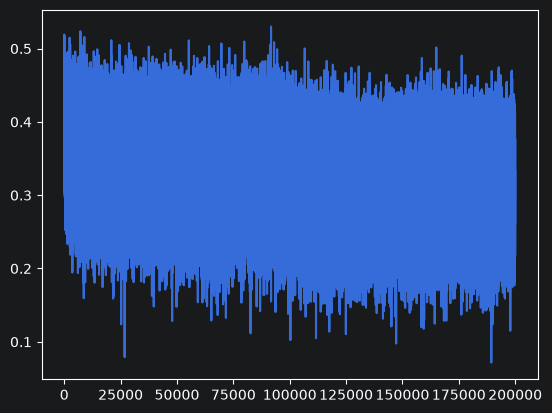

In [49]:
plt.plot(log10_minibatch_losses)

In [50]:
print_full_loss('train')
print_full_loss('val')

Full loss for the train set: 2.0698904991149902
Full loss for the val set: 2.137319564819336


### Fixing saturatedly activated $tanh$

If we are at the tails of the $tanh$, then perturbing the input to the $tanh$ will not meaningfully change the output of the $tanh$. This shall make optimization of the parameters that the input to the $tanh$ depends on much harder.

In the sense of backpropagation, this scales the global gradients flowing backward into this $tanh$ node to $0$:

`self.grad += (1 - t**2) * out.grad`

Here, `self.grad` is the gradient that the $tanh$ node pushes to its input (the quantity that becomes $0$; the $tanh$ node is essentially blocking the gradient for all paths that pass through it); `(1 - t**2)` is $d(tanh)/d(input_{tanh})$, the derivative local to this $tanh$ node (the scaling factor; when $tanh$ is roughly $1$ or $-1$, this becomes $0$); `out.grad` is, I will loosely denote it as $dL/d(tanh)$, the global gradient <ins>of the current path</ins> after this $tanh$ node.

#### Dead Neuron

If a neuron has a nonlinearity and the input to the nonlinearity with respect to every training example is in the domain where the nonlinearity has zero / near-zero gradient, then the neuron is "dead" because its weights and bias can thereafter never be updated (perturbing its weights and bias will not make any change to the loss; the gradients of the loss with respect to this neuron's weights and bias are $0$).

Moreover, even a live neuron can be "killed" (e.g., by radical learning rate, so that, after some update, the parameters jump to a region where the input to the nonlinearity with respect to every training example gives zero / near-zero gradient).